# 0. 뉴스 카테고리 다중 분류

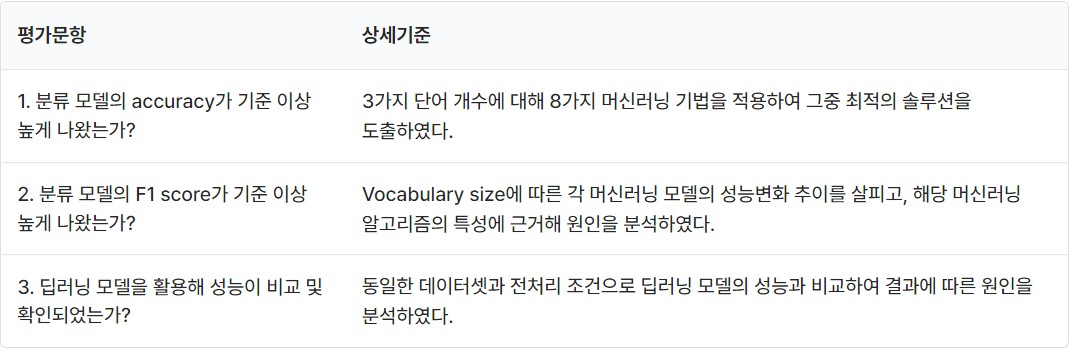

In [39]:
import sys

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer

from sklearn.naive_bayes import MultinomialNB #다항분포 나이브 베이즈 모델
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.naive_bayes import ComplementNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score #정확도 계산
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.datasets import reuters
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

# !pip install tensorflow-addons==0.16.1
import tensorflow_addons.metrics

In [2]:
tf.random.set_seed(9)
np.random.seed(9)

# 1. 데이터 확인하기

In [5]:
num_words = 10000
(train_X, train_y), (test_X, test_y) = reuters.load_data(num_words=num_words, test_split=0.2)


2121728/2110848 [==============================] - 0s 0us/step


In [6]:
print('훈련 샘플의 수: {}'.format(len(train_X)))
print('테스트 샘플의 수: {}'.format(len(test_X)))

훈련 샘플의 수: 8982
테스트 샘플의 수: 2246


In [7]:
print(train_X[0])
print(test_X[0])

[1, 2, 2, 8, 43, 10, 447, 5, 25, 207, 270, 5, 3095, 111, 16, 369, 186, 90, 67, 7, 89, 5, 19, 102, 6, 19, 124, 15, 90, 67, 84, 22, 482, 26, 7, 48, 4, 49, 8, 864, 39, 209, 154, 6, 151, 6, 83, 11, 15, 22, 155, 11, 15, 7, 48, 9, 4579, 1005, 504, 6, 258, 6, 272, 11, 15, 22, 134, 44, 11, 15, 16, 8, 197, 1245, 90, 67, 52, 29, 209, 30, 32, 132, 6, 109, 15, 17, 12]
[1, 4, 1378, 2025, 9, 697, 4622, 111, 8, 25, 109, 29, 3650, 11, 150, 244, 364, 33, 30, 30, 1398, 333, 6, 2, 159, 9, 1084, 363, 13, 2, 71, 9, 2, 71, 117, 4, 225, 78, 206, 10, 9, 1214, 8, 4, 270, 5, 2, 7, 748, 48, 9, 2, 7, 207, 1451, 966, 1864, 793, 97, 133, 336, 7, 4, 493, 98, 273, 104, 284, 25, 39, 338, 22, 905, 220, 3465, 644, 59, 20, 6, 119, 61, 11, 15, 58, 579, 26, 10, 67, 7, 4, 738, 98, 43, 88, 333, 722, 12, 20, 6, 19, 746, 35, 15, 10, 9, 1214, 855, 129, 783, 21, 4, 2280, 244, 364, 51, 16, 299, 452, 16, 515, 4, 99, 29, 5, 4, 364, 281, 48, 10, 9, 1214, 23, 644, 47, 20, 324, 27, 56, 2, 2, 5, 192, 510, 17, 12]


In [8]:
print(train_y[0])
print(test_y[0])

3
3


In [9]:
print('클래스의 수 : {}'.format(max(train_y) + 1))

클래스의 수 : 46


훈련용 뉴스의 최대 길이 :2376
훈련용 뉴스의 평균 길이 :145.5398574927633


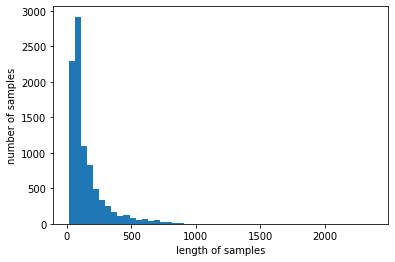

In [10]:
print('훈련용 뉴스의 최대 길이 :{}'.format(max(len(i) for i in train_X)))
print('훈련용 뉴스의 평균 길이 :{}'.format(sum(map(len, train_X))/len(train_X)))

plt.hist([len(i) for i in train_X], bins=50)
plt.xlabel('length of samples')
plt.ylabel('number of samples')
plt.show()

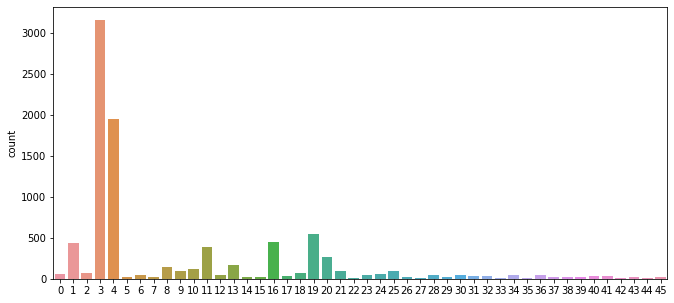

In [11]:
fig, axe = plt.subplots(ncols=1)
fig.set_size_inches(11,5)
sns.countplot(x=train_y)
plt.show()

In [12]:
print("각 클래스 빈도수:")
print(np.asarray((np.unique(train_y, return_counts=True))))

각 클래스 빈도수:
[[   0    1    2    3    4    5    6    7    8    9   10   11   12   13
    14   15   16   17   18   19   20   21   22   23   24   25   26   27
    28   29   30   31   32   33   34   35   36   37   38   39   40   41
    42   43   44   45]
 [  55  432   74 3159 1949   17   48   16  139  101  124  390   49  172
    26   20  444   39   66  549  269  100   15   41   62   92   24   15
    48   19   45   39   32   11   50   10   49   19   19   24   36   30
    13   21   12   18]]


# 2. 데이터 복원하기

In [13]:
word_index = reuters.get_word_index(path="reuters_word_index.json")

565248/550378 [==============================] - 0s 0us/step


In [14]:
index_word = {index+3: word for word, index in word_index.items()}

In [15]:
# index_word에 숫자 0은 <pad>, 숫자 1은 <sos>, 숫자 2는 <unk>를 넣어줍니다.
for index, token in enumerate(("<pad>", "<sos>", "<unk>")):
    index_word[index] = token

In [17]:
train_X = [' '.join([index_word[index] for index in train_X[i]])
                                           for i in range(len(train_X))]
print(len(train_X))
train_X[: 5]

8982


In [18]:
test_X = [' '.join([index_word[index] for index in test_X[i]])
                                           for i in range(len(test_X))]
print(len(test_X))
test_X[: 5]

2246


# 3. 벡터화 하기

In [21]:
dtm_vectorizer = CountVectorizer()
train_X = dtm_vectorizer.fit_transform(train_X)
print(train_X.shape)

(8982, 9670)


In [22]:
test_X = dtm_vectorizer.transform(test_X) #테스트 데이터를 DTM으로 변환
print(test_X.shape)

(2246, 9670)


In [23]:
tfidf_transformer = TfidfTransformer()
train_X = tfidf_transformer.fit_transform(train_X)
print(train_X.shape)

(8982, 9670)


In [24]:
test_X = tfidf_transformer.transform(test_X) #DTM을 TF-IDF 행렬로 변환
print(test_X.shape)

(2246, 9670)


# 4. 다양한 머신러닝 모델 사용해보기

##  4.1. 나이브 베이즈 분류기

In [25]:
nb = MultinomialNB()
nb.fit(train_X, train_y)

nb_predicted = nb.predict(test_X)
nb_acc = accuracy_score(test_y, nb_predicted)
nb_report = classification_report(test_y, nb_predicted, output_dict=True,
                                  zero_division=0)

print("정확도:", nb_report['accuracy'])
print("F1-Score:", nb_report['weighted avg']['f1-score'])

정확도: 0.6567230632235085
F1-Score: 0.5764467518778252


##  4.2. 컴플리먼트 나이브 베이즈 분류기

In [26]:
cnb = ComplementNB()
cnb.fit(train_X, train_y)

cnb_predicted = cnb.predict(test_X)
cnb_acc = accuracy_score(test_y, cnb_predicted)
cnb_report = classification_report(test_y, cnb_predicted, output_dict=True,
                                  zero_division=0)

print("정확도:", cnb_report['accuracy'])
print("F1-Score:", cnb_report['weighted avg']['f1-score'])

정확도: 0.7707034728406055
F1-Score: 0.7456682614453047


##  4.3. 로지스틱 회귀

In [27]:
lr = LogisticRegression(C=10000, penalty='l2', max_iter=3000)
lr.fit(train_X, train_y)

lr_predicted = lr.predict(test_X)
lr_acc = accuracy_score(test_y, lr_predicted)
lr_report = classification_report(test_y, lr_predicted, output_dict=True,
                                  zero_division=0)

print("정확도:", lr_report['accuracy'])
print("F1-Score:", lr_report['weighted avg']['f1-score'])

정확도: 0.8107747105966162
F1-Score: 0.8056804816074952


##  4.4. 선형 서포트 벡터 머신

In [28]:
lsvc = LinearSVC(C=1000, penalty='l1', max_iter=3000, dual=False)
lsvc.fit(train_X, train_y)

lsvc_predicted = lsvc.predict(test_X)
lsvc_acc = accuracy_score(test_y, lsvc_predicted)
lsvc_report = classification_report(test_y, lsvc_predicted, output_dict=True,
                                  zero_division=0)

print("정확도:", lsvc_report['accuracy'])
print("F1-Score:", lsvc_report['weighted avg']['f1-score'])

정확도: 0.782279608192342
F1-Score: 0.7790851873613297


/opt/conda/lib/python3.9/site-packages/sklearn/svm/_base.py:1199: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


##  4.5. 결정 트리

In [29]:
tree = DecisionTreeClassifier(max_depth=10)
tree.fit(train_X, train_y)

tree_predicted = tree.predict(test_X)
tree_acc = accuracy_score(test_y, tree_predicted)
tree_report = classification_report(test_y, tree_predicted, output_dict=True,
                                  zero_division=0)

print("정확도:", tree_report['accuracy'])
print("F1-Score:", tree_report['weighted avg']['f1-score'])

정확도: 0.622439893143366
F1-Score: 0.5784633565482618


##  4.6. 랜덤 포레스트

In [30]:
forest = RandomForestClassifier(n_estimators=5)
forest.fit(train_X, train_y)

forest_predicted = forest.predict(test_X)
forest_acc = accuracy_score(test_y, forest_predicted)
forest_report = classification_report(test_y, forest_predicted, output_dict=True,
                                  zero_division=0)

print("정확도:", forest_report['accuracy'])
print("F1-Score:", forest_report['weighted avg']['f1-score'])

정확도: 0.6620658949243099
F1-Score: 0.6325872912428094


##  4.7. 그래디언트 부스팅 트리

In [31]:
grbt = GradientBoostingClassifier() # verbose=3
grbt.fit(train_X, train_y)

grbt_predicted = grbt.predict(test_X)
grbt_acc = accuracy_score(test_y, grbt_predicted)
grbt_report = classification_report(test_y, grbt_predicted, output_dict=True,
                                  zero_division=0)

print("정확도:", grbt_report['accuracy'])
print("F1-Score:", grbt_report['weighted avg']['f1-score'])

정확도: 0.7595725734639359
F1-Score: 0.7569387431525992


##  4.8. 보팅

In [32]:
voting = VotingClassifier(estimators=[
         ('lr', LogisticRegression(C=10000, max_iter=3000, penalty='l2')),
        ('cb', ComplementNB()),
        ('grbt', GradientBoostingClassifier())
], voting='soft')
voting.fit(train_X, train_y)

voting_predicted = voting.predict(test_X)
voting_acc = accuracy_score(test_y, voting_predicted)
voting_report = classification_report(test_y, voting_predicted, output_dict=True,
                                  zero_division=0)

print("정확도:", voting_report['accuracy'])
print("F1-Score:", voting_report['weighted avg']['f1-score'])

정확도: 0.8165627782724845
F1-Score: 0.813723510588356


## 4.9. 모델 정확도, F1-Score 비교하기

In [33]:
table = pd.DataFrame(columns=['Accuracy', 'F1-Score'])
model_list = [nb, cnb, lr, lsvc, tree, forest, grbt, voting]

for model in model_list:
    predicted = model.predict(test_X)
    report = classification_report(test_y, predicted, output_dict=True,
                                  zero_division=0)
    model_name = model.__class__.__name__
    accuracy = report['accuracy']
    f1_score = report['weighted avg']['f1-score']
    table.loc[model_name] = [accuracy, f1_score]

table

,Accuracy,F1-Score
MultinomialNB,0.656723,0.576447
ComplementNB,0.770703,0.745668
LogisticRegression,0.810775,0.805680
LinearSVC,0.782280,0.779085
DecisionTreeClassifier,0.622440,0.578463
RandomForestClassifier,0.662066,0.632587
GradientBoostingClassifier,0.759573,0.756939
VotingClassifier,0.816563,0.813724


# 5. Vocabulary Size를 변경해서 시도해보기

In [34]:
def all_in_one(num_words):
    (X_train, y_train), (X_test, y_test) = reuters.load_data(num_words=num_words,
                                                             test_split=0.2)

    word_index = reuters.get_word_index(path="reuters_word_index.json")

    index_word = {index+3: word for word, index in word_index.items()}

    for i, token in enumerate(("<pad>", "<sos>", "<unk>")):
        index_word[i] = token

    X_train = [' '.join([index_word[index] for index in X_train[i]])
                                               for i in range(len(X_train))]

    X_test = [' '.join([index_word[index] for index in X_test[i]])
                                               for i in range(len(X_test))]

    dtm_vectorizer = CountVectorizer()
    X_train = dtm_vectorizer.fit_transform(X_train)
    X_test = dtm_vectorizer.transform(X_test)

    tfidf_transformer = TfidfTransformer()
    X_train = tfidf_transformer.fit_transform(X_train)
    X_test = tfidf_transformer.transform(X_test)

    nb = MultinomialNB()
    cnb = ComplementNB()
    lr = LogisticRegression(C=10000, penalty='l2', max_iter=3000)
    lsvc = LinearSVC(C=1000, penalty='l1', max_iter=3000, dual=False)
    tree = DecisionTreeClassifier(max_depth=10)
    forest = RandomForestClassifier(n_estimators=5)
    grbt = GradientBoostingClassifier() # verbose=3
    voting = VotingClassifier(estimators=[
             ('lr', LogisticRegression(C=10000, max_iter=3000, penalty='l2')),
            ('cb', ComplementNB()),
            ('grbt', GradientBoostingClassifier())
    ], voting='soft')

    table = pd.DataFrame(columns=['Accuracy', 'F1-Score'])
    model_list = [nb, cnb, lr, lsvc, tree, forest, grbt, voting]

    for model in model_list:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        report = classification_report(y_test, y_pred, output_dict=True,
                                      zero_division=0)
        model_name = model.__class__.__name__
        accuracy = report['accuracy']
        f1_score = report['weighted avg']['f1-score']
        table.loc[model_name] = [accuracy, f1_score]

    return table

In [35]:
num_words = 5000

globals()[f'table_{num_words}'] = all_in_one(num_words)

table_5000

/opt/conda/lib/python3.9/site-packages/sklearn/svm/_base.py:1199: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


,Accuracy,F1-Score
MultinomialNB,0.673197,0.601250
ComplementNB,0.770703,0.745899
LogisticRegression,0.803651,0.798560
LinearSVC,0.772930,0.768702
DecisionTreeClassifier,0.617097,0.572163
RandomForestClassifier,0.691006,0.666171
GradientBoostingClassifier,0.768923,0.766866
VotingClassifier,0.808994,0.805992


In [36]:
num_words = 2 ** 13

globals()[f'table_{num_words}'] = all_in_one(num_words)

table_8192

/opt/conda/lib/python3.9/site-packages/sklearn/svm/_base.py:1199: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


,Accuracy,F1-Score
MultinomialNB,0.662511,0.583264
ComplementNB,0.771149,0.747338
LogisticRegression,0.806322,0.801483
LinearSVC,0.777382,0.773202
DecisionTreeClassifier,0.623330,0.578350
RandomForestClassifier,0.678540,0.646158
GradientBoostingClassifier,0.771149,0.766336
VotingClassifier,0.815672,0.812471


# 6. 딥러닝 모델과 비교해 보기

In [30]:
# int(26506 ** 0.54 * math.log(26506, 1+0.54))
num_words = 10000
(train_X_rnn, train_y_rnn), (test_X_rnn, test_y_rnn) = reuters.load_data(
                                        num_words=num_words, test_split=0.2)

In [31]:
# point
train_X_rnn = tf.keras.preprocessing.sequence.pad_sequences(train_X_rnn,
              maxlen=2**8, padding='post', truncating='post')
test_X_rnn = tf.keras.preprocessing.sequence.pad_sequences(test_X_rnn,
              maxlen=2**8, padding='post', truncating='post')

In [32]:
train_y_rnn = tf.keras.utils.to_categorical(train_y_rnn)
test_y_rnn = tf.keras.utils.to_categorical(test_y_rnn)

In [33]:
def tsize(train_X):
    length = len(train_X)
    return round(0.14 * (1 + length / 10 ** 4) ** (10 ** 4 / length) - 0.13, 2)

tsize(train_X_rnn)


0.16

In [34]:
X_train_rnn, X_val_rnn, y_train_rnn, y_val_rnn = train_test_split(train_X_rnn,
                    train_y_rnn, test_size=tsize(train_X_rnn))


In [35]:
# point
class model_maker(tf.keras.Model):
    def __init__(self, num_words, output_dim, units):
        super().__init__()
        self.embedding = layers.Embedding(num_words, output_dim, input_shape=(None, ))
        self.lstm1 = layers.Bidirectional(layers.LSTM(units, return_sequences=True))
        self.batch1 = layers.BatchNormalization()
        self.drop1 = layers.Dropout(0.5)
        self.flatten = layers.Flatten()
        self.dense2 = layers.Dense(46, activation='softmax')
        
    def call(self, x):
        x = self.embedding(x)
        x = self.lstm1(x)
        x = self.batch1(x)
        x = self.drop1(x)
        x = self.flatten(x)
        x = self.dense2(x)
        
        return x


In [36]:
# point
output_dim = 2 ** 8
units = 2 ** 6

model = model_maker(num_words, output_dim, units)

In [37]:
print(sys.version)
print(tf.__version__)

# !pip install tensorflow-addons==0.16.1
# import tensorflow_addons.metrics

3.9.7 | packaged by conda-forge | (default, Sep 29 2021, 19:20:46) 
[GCC 9.4.0]
2.6.0


In [40]:
model.compile(optimizer='Adam', loss='categorical_crossentropy',
              metrics=[tensorflow_addons.metrics.F1Score(num_classes=46, average='weighted')])

epochs = 2 ** 5

early_stop = EarlyStopping(monitor='val_loss', verbose=1, patience=2**3)

history = model.fit(X_train_rnn,
                    y_train_rnn,
                    epochs=epochs,
                    batch_size=2**6, # point
                    validation_data=(X_val_rnn, y_val_rnn),
                    verbose=1,
                    callbacks=[early_stop])

Epoch 1/32
118/118 [==============================] - 7s 31ms/step - loss: 1.5560 - f1_score: 0.6531 - val_loss: 3.1414 - val_f1_score: 0.3713
Epoch 2/32
118/118 [==============================] - 3s 24ms/step - loss: 0.4038 - f1_score: 0.9357 - val_loss: 2.7016 - val_f1_score: 0.5464
Epoch 3/32
118/118 [==============================] - 3s 25ms/step - loss: 0.3561 - f1_score: 0.9525 - val_loss: 2.2731 - val_f1_score: 0.6973
Epoch 4/32
118/118 [==============================] - 3s 24ms/step - loss: 0.3312 - f1_score: 0.9554 - val_loss: 1.5756 - val_f1_score: 0.7164
Epoch 5/32
118/118 [==============================] - 3s 24ms/step - loss: 0.2959 - f1_score: 0.9584 - val_loss: 1.1978 - val_f1_score: 0.7362
Epoch 6/32
118/118 [==============================] - 3s 24ms/step - loss: 0.2770 - f1_score: 0.9589 - val_loss: 1.1339 - val_f1_score: 0.7316
Epoch 7/32
118/118 [==============================] - 3s 24ms/step - loss: 0.2517 - f1_score: 0.9607 - val_loss: 1.2502 - val_f1_score: 0.7525

In [41]:
result = model.evaluate(test_X_rnn, test_y_rnn, verbose=1)

71/71 [==============================] - 1s 8ms/step - loss: 1.1336 - f1_score: 0.7689
